# Chapter 41 Lab — Biomarkers and Translational Neuroscience (Python)

In this lab you will build the quantitative toolkit for evaluating brain-based biomarkers: converters among effect size ($d$), classification accuracy, AUC, and number needed to treat (NNT); a simulation of the **winner's curse** showing why discovery effect sizes shrink on replication; and a **diagnostic testing** analysis showing how base rates govern the meaning of a positive test.

*How to run this:* This notebook runs in your browser (via Pyodide), on Colab, or locally — it uses only numpy, scipy, and matplotlib on simulated data, so no downloads are needed. Run cells top to bottom. It accompanies the chapter page [41. Biomarkers and Translational Neuroscience](https://torwager.github.io/elements-of-fmri-tutorials/book/part7/ch41-biomarkers-and-translational-neuroscience).

*Code adapted from CANlab FMRI_simulations (github.com/canlab): `effect_size_formulas.m`, `effect_size_vs_classification_accuracy.m`, `Cohens_d_to_NNT.mlx`, `effect_size_inflation_example_sim.m`, and `diagnostic_testing.m`.*

## Part 1 — Effect size converters

Under a normal, equal-variance model — controls $\sim N(0, 1)$, patients $\sim N(d, 1)$ — the key clinical performance metrics are exact functions of $d$:

- **Point-biserial correlation:** $r = d / \sqrt{d^2 + 4}$
- **Forced-choice accuracy** (given one patient and one control, pick the patient) — which equals the **area under the ROC curve**: $\mathrm{AUC} = \Phi(d/\sqrt{2})$
- **Single-interval accuracy** (classify one person against a fixed cutpoint): $\Phi(d/2)$
- **Number needed to treat** (Furukawa): $\mathrm{NNT} = 1 / \left[\Phi\left(d + \Phi^{-1}(\mathrm{CER})\right) - \mathrm{CER}\right]$, where CER is the control-group event rate

Forced choice is easier than single-interval classification (you get to compare two observations), so the same $d$ yields higher accuracy.

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import pandas as pd

# Effect size converters (normal, equal-variance model)
d2r        = lambda d: d / np.sqrt(d**2 + 4)            # d -> point-biserial r
r2d        = lambda r: 2 * r / np.sqrt(1 - r**2)        # r -> d
d2acc_forc = lambda d: norm.cdf(d / np.sqrt(2))         # forced-choice acc = AUC
d2acc_sing = lambda d: norm.cdf(d / 2)                  # single-interval accuracy
acc2d_sing = lambda a: 2 * norm.ppf(a)                  # accuracy -> required d
d2nnt      = lambda d, cer: 1 / (norm.cdf(d + norm.ppf(cer)) - cer)  # Furukawa
auc2nnt    = lambda auc: 1 / (2 * auc - 1)              # Kraemer & Kupfer

# Reference table: small / medium / large effects, plus the NPS response
# to evoked pain (d = 2.32 across 20 independent studies)
d_ref = np.array([0.2, 0.5, 0.8, 1.5, 2.32])
table = pd.DataFrame({
    "d": d_ref,
    "r": d2r(d_ref).round(2),
    "acc_single": (100 * d2acc_sing(d_ref)).round(1),
    "AUC": d2acc_forc(d_ref).round(3),
    "NNT (CER=0.5)": d2nnt(d_ref, 0.5).round(1),
})
print(table.to_string(index=False))
print(f"\nd required for 90% accuracy, single interval: {acc2d_sing(0.9):.2f}")
print(f"d required for 90% accuracy, forced choice:   {np.sqrt(2)*norm.ppf(0.9):.2f}")

   d    r  acc_single   AUC  NNT (CER=0.5)
0.20 0.10        54.0 0.556           12.6
0.50 0.24        59.9 0.638            5.2
0.80 0.37        65.5 0.714            3.5
1.50 0.60        77.3 0.856            2.3
2.32 0.76        87.7 0.950            2.0

d required for 90% accuracy, single interval: 2.56
d required for 90% accuracy, forced choice:   1.81


Note the punchline: a conventionally "large" effect of $d = 0.8$ classifies individuals at only ~66% — barely better than a coin flip. Confident individual-level decisions require effects in the $d \ge 2$ range, like the NPS response to evoked pain.

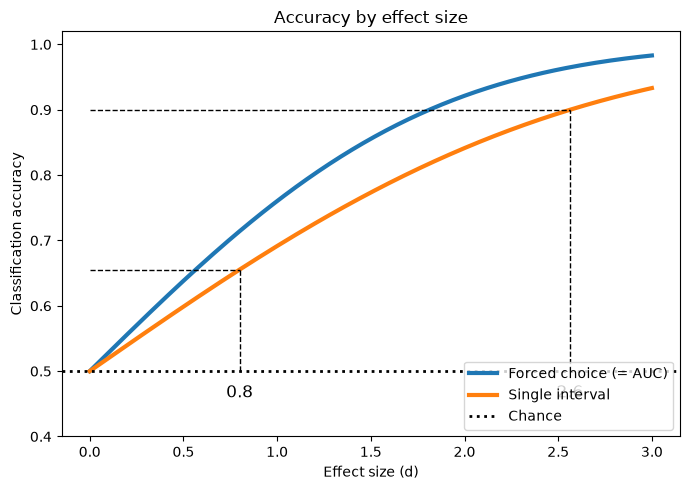

In [2]:
# Plot accuracy and AUC as a function of d
d = np.arange(0, 3.01, 0.02)       # effect sizes to plot, 0 to 3

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(d, d2acc_forc(d), lw=3, label="Forced choice (= AUC)")
ax.plot(d, d2acc_sing(d), lw=3, label="Single interval")
ax.axhline(0.5, ls=":", color="k", lw=2, label="Chance")

# Crosshairs: what does d = 0.8 buy you? What d do you need for 90%?
for d_mark, acc_fun in [(0.8, d2acc_sing), (acc2d_sing(0.9), d2acc_sing)]:
    a = acc_fun(d_mark)
    ax.plot([d_mark, d_mark], [0.5, a], "k--", lw=1)
    ax.plot([0, d_mark], [a, a], "k--", lw=1)
    ax.text(d_mark, 0.46, f"{d_mark:.1f}", ha="center", fontsize=12)

ax.set(xlabel="Effect size (d)", ylabel="Classification accuracy",
       ylim=(0.4, 1.02), title="Accuracy by effect size")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Part 2 — Verify the formulas by simulation

Formulas are only trustworthy if we can reproduce them from first principles. Simulate a large sample of controls and patients and measure both kinds of accuracy empirically.

In [3]:
rng = np.random.default_rng(1)     # seed for reproducibility
d_true, n = 0.8, 200_000           # d_true = group separation; n = draws per group

controls = rng.standard_normal(n)            # N(0, 1)
patients = d_true + rng.standard_normal(n)   # N(d, 1)

# Forced choice: pair one patient with one control, pick the higher score
emp_forced = np.mean(patients > controls)

# Single interval: classify one observation against the optimal cutpoint
# (midway between the means when variances are equal)
cut = d_true / 2
emp_single = np.mean(np.concatenate([patients > cut, controls <= cut]))

# AUC computed nonparametrically from the ROC (rank statistic)
emp_auc = stats.mannwhitneyu(patients, controls).statistic / n**2

print(f"Forced choice:   theory {d2acc_forc(d_true):.3f}, simulated {emp_forced:.3f}")
print(f"Single interval: theory {d2acc_sing(d_true):.3f}, simulated {emp_single:.3f}")
print(f"AUC:             theory {d2acc_forc(d_true):.3f}, simulated {emp_auc:.3f}")

Forced choice:   theory 0.714, simulated 0.714
Single interval: theory 0.655, simulated 0.656
AUC:             theory 0.714, simulated 0.715


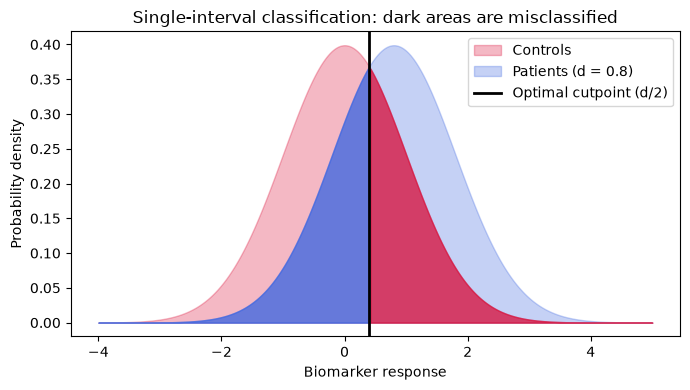

In [4]:
# Visualize the two class distributions and the misclassification zones
x = np.linspace(-4, 5, 400)
f_ctrl, f_pat = norm.pdf(x), norm.pdf(x, loc=d_true)

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(x, f_ctrl, alpha=0.3, color="crimson", label="Controls")
ax.fill_between(x, f_pat, alpha=0.3, color="royalblue", label=f"Patients (d = {d_true})")
ax.axvline(cut, color="k", lw=2, label="Optimal cutpoint (d/2)")
ax.fill_between(x[x >= cut], f_ctrl[x >= cut], color="crimson", alpha=0.7)
ax.fill_between(x[x < cut], f_pat[x < cut], color="royalblue", alpha=0.7)
ax.set(xlabel="Biomarker response", ylabel="Probability density",
       title="Single-interval classification: dark areas are misclassified")
ax.legend()
plt.tight_layout()
plt.show()

## Part 3 — From $d$ to number needed to treat

NNT answers the clinician's question: *how many patients must I treat for one additional success relative to control?* It is the reciprocal of the difference in event rates, $\mathrm{NNT} = 1/(\mathrm{EER} - \mathrm{CER})$.

Converting a continuous effect $d$ to NNT requires defining a "response" threshold on the outcome scale, summarized by the control event rate (CER). We verify Furukawa's formula by direct simulation, and compare the threshold-free Kraemer & Kupfer variant, $\mathrm{NNT} = 1/(2\,\mathrm{AUC} - 1)$.

In [5]:
d_true = 0.5                       # treatment effect size
thr = 0.0                          # response = outcome above this threshold
cer = 1 - norm.cdf(thr)            # control event rate = 0.5 here

x_ctrl  = rng.standard_normal(n)
x_treat = d_true + rng.standard_normal(n)
eer_emp, cer_emp = np.mean(x_treat > thr), np.mean(x_ctrl > thr)
nnt_emp = 1 / (eer_emp - cer_emp)

print(f"NNT at d = {d_true}, CER = {cer:.2f}:")
print(f"  Furukawa formula:  {d2nnt(d_true, cer):.1f}")
print(f"  Direct simulation: {nnt_emp:.1f}")
print(f"  Kraemer & Kupfer (threshold-free): {auc2nnt(d2acc_forc(d_true)):.1f}")

NNT at d = 0.5, CER = 0.50:
  Furukawa formula:  5.2
  Direct simulation: 5.2
  Kraemer & Kupfer (threshold-free): 3.6


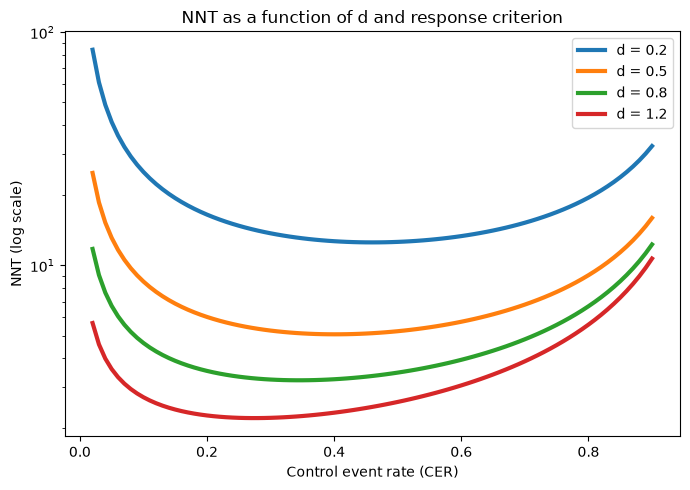

With d = 0.5, NNT ranges from 5 (lenient criterion, CER = 0.5) to 25 (stringent criterion, CER = 0.02).


In [6]:
# NNT depends strongly on the response criterion
cer_vals = np.arange(0.02, 0.91, 0.01)   # response criteria, stringent to lenient

fig, ax = plt.subplots(figsize=(7, 5))
for d_val in [0.2, 0.5, 0.8, 1.2]:       # effect sizes to compare
    ax.plot(cer_vals, d2nnt(d_val, cer_vals), lw=3, label=f"d = {d_val}")
ax.set_yscale("log")
ax.set(xlabel="Control event rate (CER)", ylabel="NNT (log scale)",
       title="NNT as a function of d and response criterion")
ax.legend()
plt.tight_layout()
plt.show()

print("With d = 0.5, NNT ranges from "
      f"{d2nnt(0.5, 0.5):.0f} (lenient criterion, CER = 0.5) to "
      f"{d2nnt(0.5, 0.02):.0f} (stringent criterion, CER = 0.02).")

The same drug, the same $d$ — but the NNT can differ by an order of magnitude depending on how "response" is defined. Clinical claims are meaningless without the criterion attached.

## Part 4 — The winner's curse: inflated discovery effect sizes

When many tests are performed (voxels, regions, candidate models) and results are *selected* for significance or top performance, the selected effect sizes are biased upward — a significant result in a small sample **must** have a large observed effect, and chance supplied part of it. We simulate a discovery study with 5,000 voxels that all carry the same true effect, select the significant ones, then re-measure exactly those voxels in an independent replication study.

In [7]:
rng = np.random.default_rng(42)    # seed for reproducibility
n_vox, n_sub, d_true = 5000, 20, 0.5   # tests (voxels), subjects, true effect everywhere
alpha_v = 0.001                    # voxelwise significance threshold

# Discovery study: one-sample t-test at each voxel (subjects x voxels)
Y_disc = d_true + rng.standard_normal((n_sub, n_vox))
t_disc, p_disc = stats.ttest_1samp(Y_disc, 0)
d_disc = Y_disc.mean(axis=0) / Y_disc.std(axis=0, ddof=1)   # observed d

sig = (p_disc < alpha_v) & (d_disc > 0)
print(f"{sig.sum()} of {n_vox} voxels significant at p < {alpha_v}")

# Replication study: same voxels, new subjects, NO selection
Y_rep = d_true + rng.standard_normal((n_sub, n_vox))
d_rep = Y_rep.mean(axis=0) / Y_rep.std(axis=0, ddof=1)

print(f"True d everywhere:                              {d_true:.2f}")
print(f"Mean observed d, significant voxels (discovery): {d_disc[sig].mean():.2f}")
print(f"Mean observed d, same voxels (replication):      {d_rep[sig].mean():.2f}")

408 of 5000 voxels significant at p < 0.001
True d everywhere:                              0.50
Mean observed d, significant voxels (discovery): 1.02
Mean observed d, same voxels (replication):      0.54


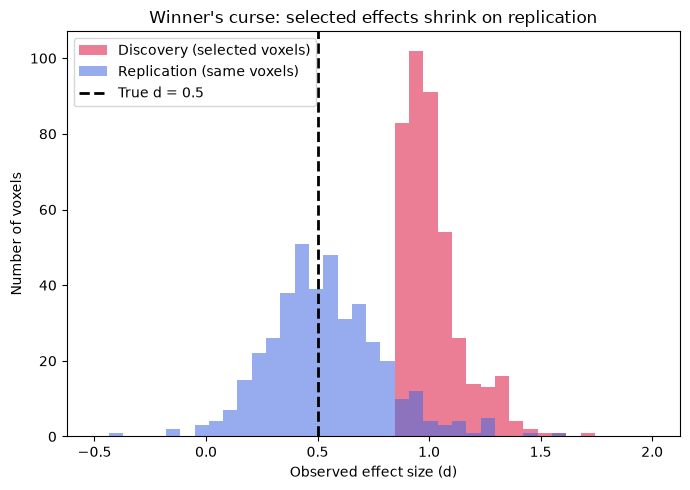

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(-0.5, 2.0, 40)
ax.hist(d_disc[sig], bins=bins, alpha=0.55, color="crimson",
        label="Discovery (selected voxels)")
ax.hist(d_rep[sig], bins=bins, alpha=0.55, color="royalblue",
        label="Replication (same voxels)")
ax.axvline(d_true, color="k", ls="--", lw=2, label=f"True d = {d_true}")
ax.set(xlabel="Observed effect size (d)", ylabel="Number of voxels",
       title="Winner's curse: selected effects shrink on replication")
ax.legend()
plt.tight_layout()
plt.show()

The significant voxels looked like $d \approx 1$ in the discovery sample — double the truth. In the replication sample, the *same voxels* return to an unbiased $d \approx 0.5$. Nothing about the brain changed; only the selection did. The same mechanism inflates cross-validated accuracy when analysts try several models and report the best one.

**How bad can it get?** Even with *no true effect anywhere*, selecting the maximum across many tests manufactures large apparent effects — worse for small samples:

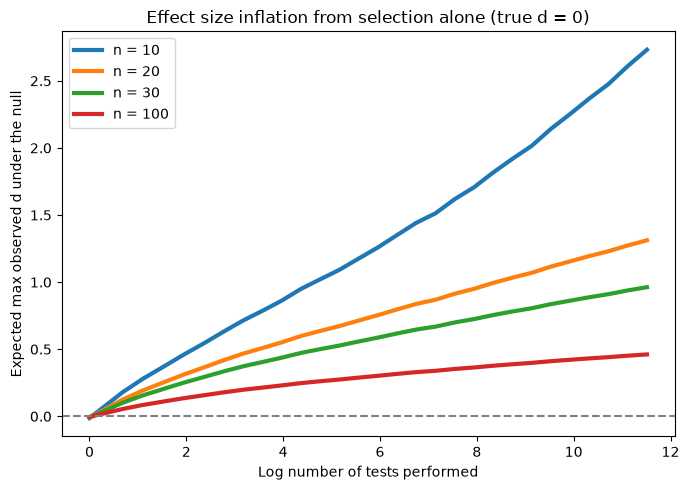

In [9]:
# Expected max-|Z| across v null tests, converted to d for several sample sizes
# (adapted from expected_effect_size_inflation_curve.m)
rng = np.random.default_rng(7)     # seed for reproducibility
n_tests = np.unique(np.round(np.logspace(0, 5, 30)).astype(int))  # number of tests: 1 to 100,000
n_vals = [10, 20, 30, 100]         # sample sizes to compare
nsim = 2000                        # simulations per point; more gives smoother curves

d_inflate = np.zeros((len(n_tests), len(n_vals)))
for v, nt in enumerate(n_tests):
    # expected maximum Z across nt independent null tests
    z_max = rng.standard_normal((nsim, nt)).max(axis=1).mean()
    p_max = 1 - norm.cdf(z_max)
    for i, n_s in enumerate(n_vals):
        t_equiv = stats.t.ppf(1 - p_max, df=n_s - 1)
        d_inflate[v, i] = t_equiv / np.sqrt(n_s)

fig, ax = plt.subplots(figsize=(7, 5))
for i, n_s in enumerate(n_vals):
    ax.plot(np.log(n_tests), d_inflate[:, i], lw=3, label=f"n = {n_s}")
ax.axhline(0, ls="--", color="gray")
ax.set(xlabel="Log number of tests performed",
       ylabel="Expected max observed d under the null",
       title="Effect size inflation from selection alone (true d = 0)")
ax.legend()
plt.tight_layout()
plt.show()

With $n = 20$ and hundreds of thousands of voxel tests, the *expected* maximum effect under the pure null already exceeds $d = 1$ — "whopping" effects can be produced by selection alone. This is why unbiased effect sizes and performance estimates require **prospective tests on independent data with all model parameters frozen**.

## Part 5 — Diagnostic testing: base rates and PPV

Sensitivity and specificity are properties of the *test*. But the question a patient cares about — *given a positive result, do I have the condition?* — is the **positive predictive value**, and it depends on the prevalence (base rate) in the tested population:

::::{div}
:class: eq-tip
$$
\mathrm{PPV} = \frac{\mathrm{sens} \cdot \mathrm{prev}}{\mathrm{sens} \cdot \mathrm{prev} + (1 - \mathrm{spec})(1 - \mathrm{prev})}
$$
:::{div}
:class: eq-tip-text
PPV — probability that a positive test is a true positive · sens — sensitivity: P(test + | condition present) · spec — specificity: P(test − | condition absent) · prev — prevalence (base rate) in the tested population
:::
::::
:::{div}
:class: eq-where
*where* $\mathrm{PPV}$ *is the probability that a positive test is a true positive,* $\mathrm{sens}$ *the sensitivity,* $\mathrm{spec}$ *the specificity, and* $\mathrm{prev}$ *the prevalence of the condition in the tested population.*
:::

In [10]:
def calc_ppv(sens, spec, prev):
    return sens * prev / (sens * prev + (1 - spec) * (1 - prev))

def calc_npv(sens, spec, prev):
    return spec * (1 - prev) / ((1 - sens) * prev + spec * (1 - prev))

# An excellent test meets a rare condition
for sens, spec, prev in [(.98, .98, .10), (.98, .98, .01), (.98, .98, .001),
                         (.98, .999, .001)]:
    print(f"sens {sens:.0%}, spec {spec:.1%}, prevalence {prev:.1%}: "
          f"PPV = {calc_ppv(sens, spec, prev):.2f}")

sens 98%, spec 98.0%, prevalence 10.0%: PPV = 0.84
sens 98%, spec 98.0%, prevalence 1.0%: PPV = 0.33
sens 98%, spec 98.0%, prevalence 0.1%: PPV = 0.05
sens 98%, spec 99.9%, prevalence 0.1%: PPV = 0.50


Even at 98% sensitivity *and* specificity, a positive test for a condition affecting 1% of people is correct only one time in three — and for a 1-in-1000 condition, specificity must approach 99.9% before PPV is even a coin flip. This is why screening for rare disorders is so hard, and why a brain biomarker's specificity must be established against *many* alternative conditions, not just healthy controls.

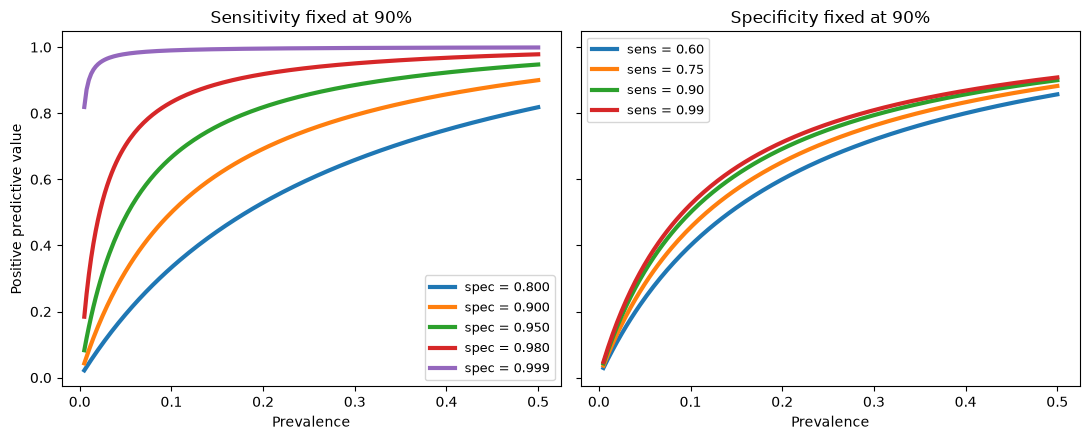

In [11]:
# PPV as a function of prevalence and test properties
prev = np.linspace(0.005, 0.5, 200)      # prevalence (base rate) range to sweep
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for spec in [0.80, 0.90, 0.95, 0.98, 0.999]:
    axes[0].plot(prev, calc_ppv(0.90, spec, prev), lw=3, label=f"spec = {spec:.3f}")
axes[0].set(xlabel="Prevalence", ylabel="Positive predictive value",
            title="Sensitivity fixed at 90%")
axes[0].legend(fontsize=9)

for sens in [0.60, 0.75, 0.90, 0.99]:
    axes[1].plot(prev, calc_ppv(sens, 0.90, prev), lw=3, label=f"sens = {sens:.2f}")
axes[1].set(xlabel="Prevalence", title="Specificity fixed at 90%")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Compare the two panels: varying **specificity** fans the curves apart dramatically, while varying **sensitivity** barely moves them. PPV is driven by specificity and prevalence; sensitivity matters mainly for the *negative* predictive value.

**A realistic scenario.** Current brain biomarkers for chronic pain classify patients vs. healthy controls at roughly 90% sensitivity / 80% specificity. Suppose one is deployed in a clinic where 20% of tested patients truly have the target condition:

In [12]:
sens, spec, prev = 0.90, 0.80, 0.20    # test properties; prev = clinic base rate
print(f"Realistic biomarker (sens {sens:.0%}, spec {spec:.0%}, prev {prev:.0%}):")
print(f"  PPV = {calc_ppv(sens, spec, prev):.2f}   "
      f"(a positive test is right about half the time)")
print(f"  NPV = {calc_npv(sens, spec, prev):.2f}   "
      f"(a negative test is quite reassuring)")
print()
print("Where should development effort go?")
print(f"  Improve specificity to 95%: PPV -> {calc_ppv(0.90, 0.95, prev):.2f}")
print(f"  Improve sensitivity to 99%: PPV -> {calc_ppv(0.99, 0.80, prev):.2f}")

# Expected performance per 1000 patients tested
n_pop = 1000                           # hypothetical number of patients tested
tp = sens * prev * n_pop; fp = (1 - spec) * (1 - prev) * n_pop
fn = (1 - sens) * prev * n_pop; tn = spec * (1 - prev) * n_pop
print(f"\nPer 1000 patients: {tp:.0f} true pos, {fp:.0f} FALSE pos, "
      f"{tn:.0f} true neg, {fn:.0f} false neg")

Realistic biomarker (sens 90%, spec 80%, prev 20%):
  PPV = 0.53   (a positive test is right about half the time)
  NPV = 0.97   (a negative test is quite reassuring)

Where should development effort go?
  Improve specificity to 95%: PPV -> 0.82
  Improve sensitivity to 99%: PPV -> 0.55

Per 1000 patients: 180 true pos, 160 FALSE pos, 640 true neg, 20 false neg


## Wrap-up

1. **Effect sizes translate into clinical metrics** — $r$, accuracy, AUC, and NNT are interconvertible under normal assumptions. Report the ones that answer the clinical question, with criteria attached.
2. **A "large" effect is not a biomarker.** $d = 0.8$ classifies individuals at ~66%; useful individual-level decisions need $d \gtrsim 2$, achievable so far mainly for states like evoked pain rather than trait diagnoses.
3. **Selection inflates.** Effects chosen for significance or top performance shrink on replication; only prospective tests of frozen models on independent data give unbiased estimates.
4. **Base rates rule deployment.** PPV depends on prevalence and specificity; a biomarker validated against healthy controls at 80% specificity yields only ~50% PPV in realistic clinical use — specificity against *other conditions* is the frontier.

These are the quantitative teeth behind the chapter's five criteria for useful brain signatures: precise definition, person-level diagnosticity, interpretability, deployability, and generalizability.